In [12]:
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print("Ready.")

Ready.


In [ ]:
def load_orl(data_dir):
    X, y, imgs = [], [], []
    for s in range(1, 41):
        d = os.path.join(data_dir, f's{s}')
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            if f.lower().endswith(('.pgm','.png','.jpg','.jpeg')):
                a = np.array(Image.open(os.path.join(d,f)).convert('L'), dtype=np.float64)
                imgs.append(a); X.append(a.flatten()); y.append(s)
    return np.array(X), np.array(y), np.array(imgs)

DATA_DIR = "/kaggle/input/datasets/kasikrit/att-database-of-faces"
X, y, images = load_orl(DATA_DIR)
H, W = images.shape[1], images.shape[2]
C = len(np.unique(y))

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"X: {X.shape} | Train: {Xtr.shape} | Test: {Xte.shape} | Classes: {C}")

X: (400, 10304) | Train: (280, 10304) | Test: (120, 10304) | Classes: 40


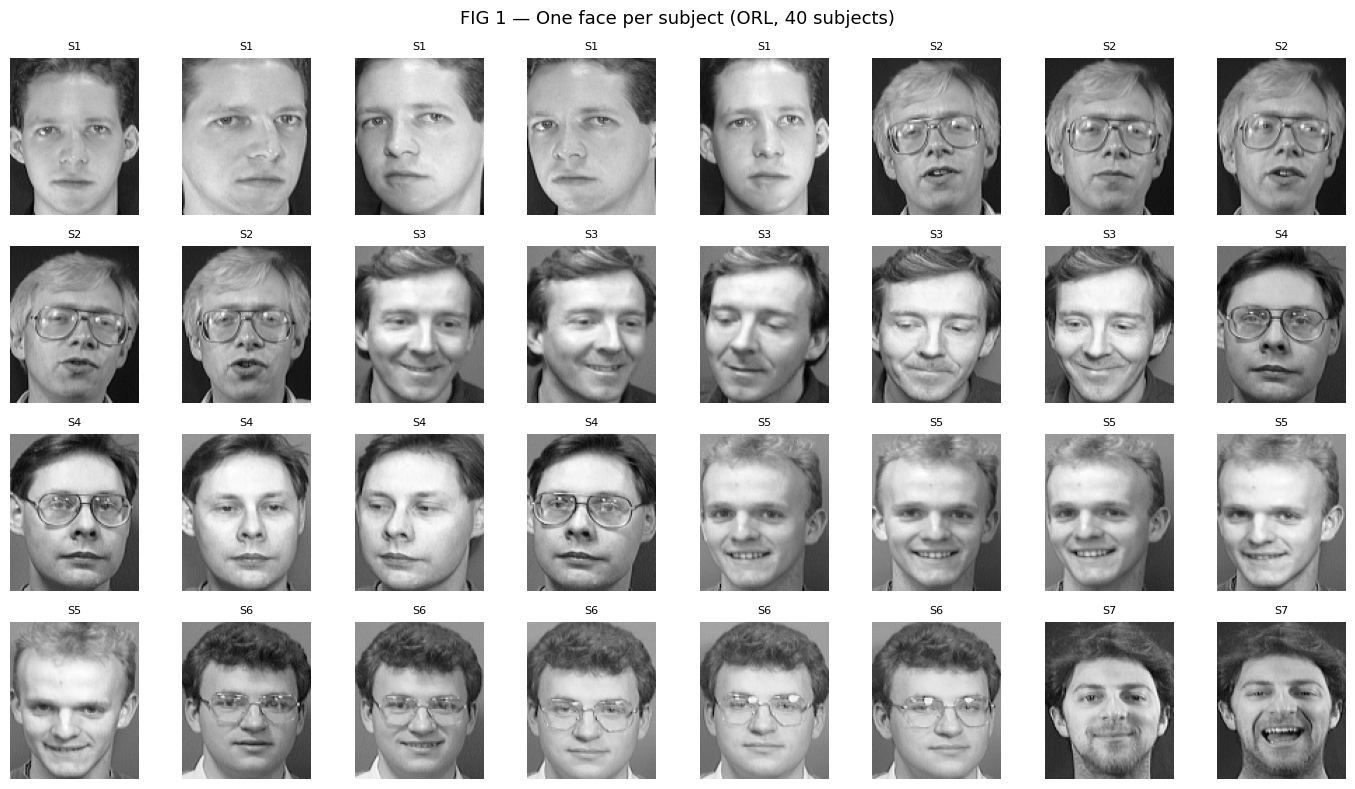

In [14]:
fig, ax = plt.subplots(4, 8, figsize=(14, 8))
for i, a in enumerate(ax.flat):
    a.imshow(images[i*2], cmap='gray'); a.set_title(f"S{y[i*2]}", fontsize=8); a.axis('off')
plt.suptitle("FIG 1 — One face per subject (ORL, 40 subjects)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
mu = Xtr.mean(axis=0)                     
Xtr_c = Xtr - mu                          
Xte_c = Xte - mu

cov = (Xtr_c.T @ Xtr_c) / (Xtr_c.shape[0] - 1)
pca_vals, pca_vecs = np.linalg.eigh(cov)                
pca_order = np.argsort(pca_vals)[::-1]
pca_vals = pca_vals[pca_order]
pca_vecs = pca_vecs[:, pca_order]
V_pca = pca_vecs.T                                       
pca_explained = pca_vals / pca_vals.sum()
pca_cum = np.cumsum(pca_explained)

# info, singular values, direction vectors.
U_svd, S_svd, Vt_svd = np.linalg.svd(Xtr, full_matrices=False)   
svd_energy = (S_svd**2) / np.sum(S_svd**2)
svd_cum = np.cumsum(svd_energy)

# logic is ki we need Sw (within-class scatter) and Sb (between-class scatter) to compute LDA.
# but to calculate them LDA can find only c - 1 directions so we do dimenstionalty reductions using pcs first
K_pre = 100
from sklearn.decomposition import PCA as skPCA
pre = skPCA(n_components=K_pre, whiten=True, random_state=42).fit(Xtr)
Xtr_p = pre.transform(Xtr); Xte_p = pre.transform(Xte)

lda = LinearDiscriminantAnalysis(solver='svd', n_components=min(C-1, K_pre))
Ztr_lda = lda.fit_transform(Xtr_p, ytr)
Zte_lda = lda.transform(Xte_p)
W_lda = lda.scalings_                                  # in PCA space

def proj_pca(Xraw, k):  return (Xraw - mu) @ V_pca[:k].T
def rec_pca(Z, k):      return Z @ V_pca[:k] + mu
def proj_svd(Xraw, k):  return Xraw @ Vt_svd[:k].T           # uncentered
def rec_svd(Z, k):      return Z @ Vt_svd[:k]                # no mean added
def proj_lda(Xraw, k):
    return ((Xraw - pre.mean_) @ pre.components_[:K_pre].T / np.sqrt(pre.explained_variance_)) @ W_lda[:, :k]

print("PCA basis:", V_pca.shape, "| SVD basis:", Vt_svd.shape, "| LDA basis:", W_lda.shape)
print("Top-5 PCA λ: ", pca_vals[:5])
print("Top-5 SVD σ: ", S_svd[:5])
print("Top-5 LDA λ: ", lda.explained_variance_ratio_[:5])

PCA basis: (10304, 10304) | SVD basis: (280, 10304) | LDA basis: (100, 39)
Top-5 PCA λ:  [2818488.09588931 2085909.67672283 1100843.89300518  895815.8431584
  827834.77093505]
Top-5 SVD σ:  [199645.85623477  25943.20801291  17682.04402848  16774.54196883
  15791.27987116]
Top-5 LDA λ:  [0.18738685 0.128508   0.09900059 0.0654147  0.06065302]


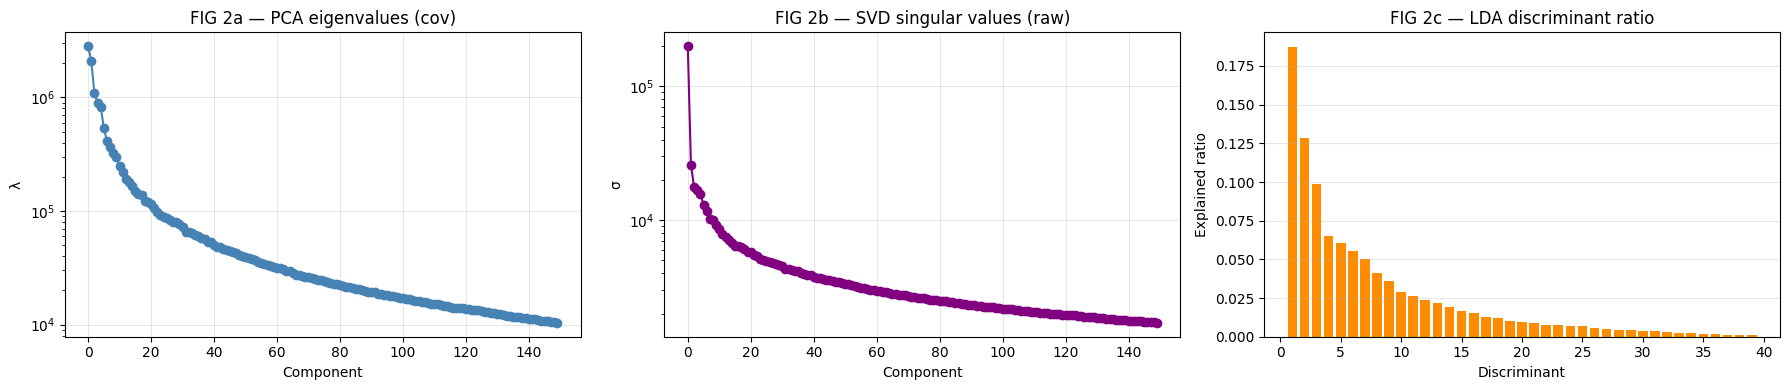

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].semilogy(pca_vals[:150], 'o-', color='steelblue')
ax[0].set_title("FIG 2a — PCA eigenvalues (cov)"); ax[0].set_xlabel("Component")
ax[0].set_ylabel("λ"); ax[0].grid(alpha=.3)

ax[1].semilogy(S_svd[:150], 'o-', color='purple')
ax[1].set_title("FIG 2b — SVD singular values (raw)"); ax[1].set_xlabel("Component")
ax[1].set_ylabel("σ"); ax[1].grid(alpha=.3)

ax[2].bar(range(1, len(lda.explained_variance_ratio_)+1),
          lda.explained_variance_ratio_, color='darkorange')
ax[2].set_title("FIG 2c — LDA discriminant ratio"); ax[2].set_xlabel("Discriminant")
ax[2].set_ylabel("Explained ratio"); ax[2].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

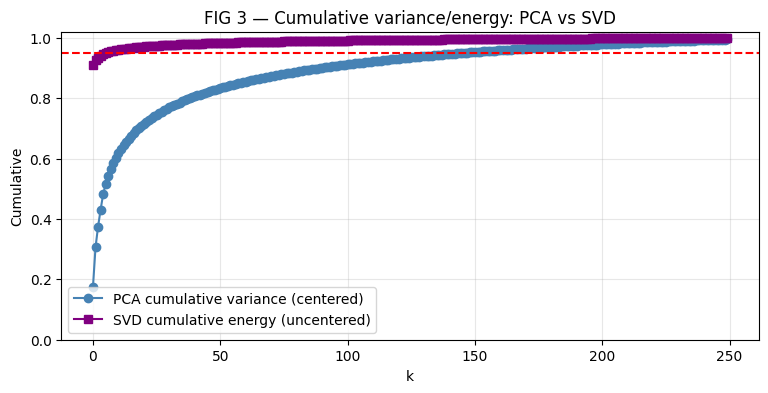

95% variance reached at k_PCA=147,  k_SVD=7


In [17]:
plt.figure(figsize=(9, 4))
plt.plot(pca_cum[:250], 'o-', color='steelblue', label='PCA cumulative variance (centered)')
plt.plot(svd_cum[:250], 's-', color='purple',   label='SVD cumulative energy (uncentered)')
plt.axhline(0.95, ls='--', color='r')
plt.xlabel("k"); plt.ylabel("Cumulative"); plt.ylim(0, 1.02)
plt.title("FIG 3 — Cumulative variance/energy: PCA vs SVD")
plt.legend(); plt.grid(alpha=.3); plt.show()

# k needed for 95 %
k_pca_95 = int(np.searchsorted(pca_cum, 0.95) + 1)
k_svd_95 = int(np.searchsorted(svd_cum, 0.95) + 1)
print(f"95% variance reached at k_PCA={k_pca_95},  k_SVD={k_svd_95}")

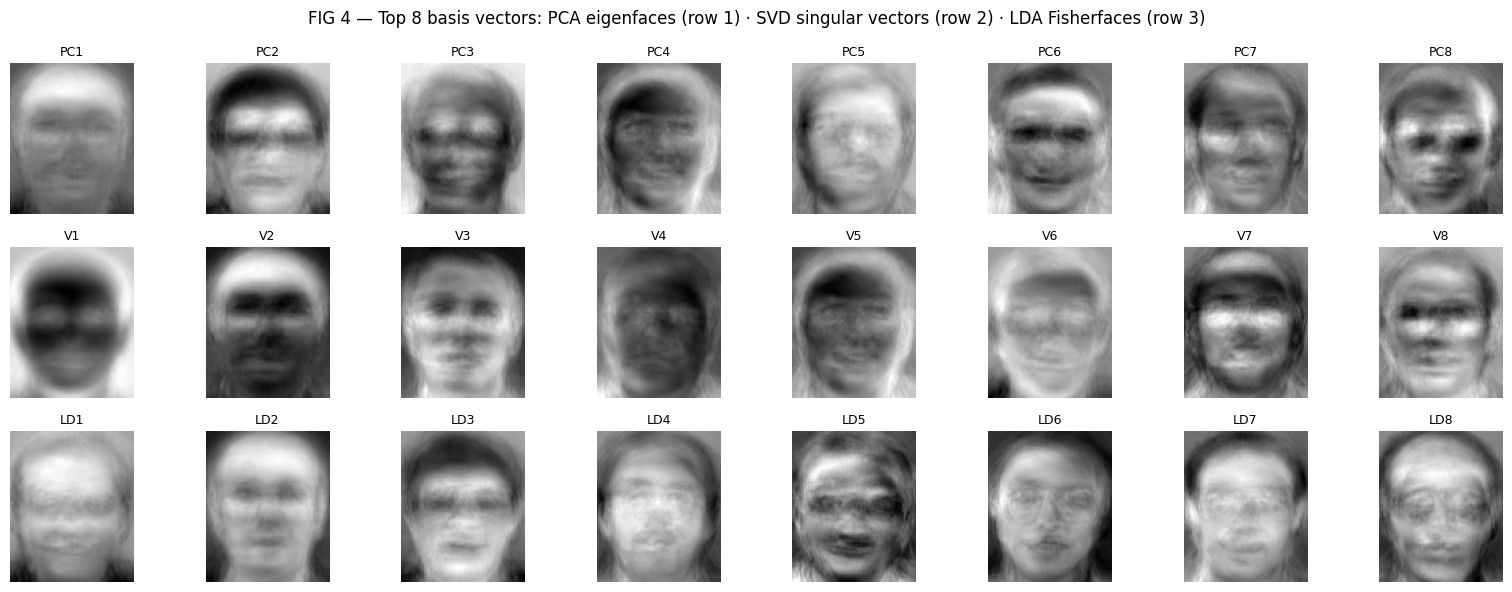

In [18]:
fig, ax = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    ax[0, i].imshow(V_pca[i].reshape(H, W), cmap='gray')
    ax[0, i].set_title(f"PC{i+1}", fontsize=9); ax[0, i].axis('off')

    ax[1, i].imshow(Vt_svd[i].reshape(H, W), cmap='gray')
    ax[1, i].set_title(f"V{i+1}", fontsize=9); ax[1, i].axis('off')

    fisher_pixels = pre.inverse_transform(W_lda[:, i].reshape(1, -1)).reshape(H, W)
    ax[2, i].imshow(fisher_pixels, cmap='gray')
    ax[2, i].set_title(f"LD{i+1}", fontsize=9); ax[2, i].axis('off')

ax[0,0].set_ylabel("PCA", fontsize=11)
ax[1,0].set_ylabel("SVD", fontsize=11)
ax[2,0].set_ylabel("LDA", fontsize=11)
plt.suptitle("FIG 4 — Top 8 basis vectors: PCA eigenfaces (row 1) · SVD singular vectors (row 2) · LDA Fisherfaces (row 3)", fontsize=12)
plt.tight_layout(); plt.show()

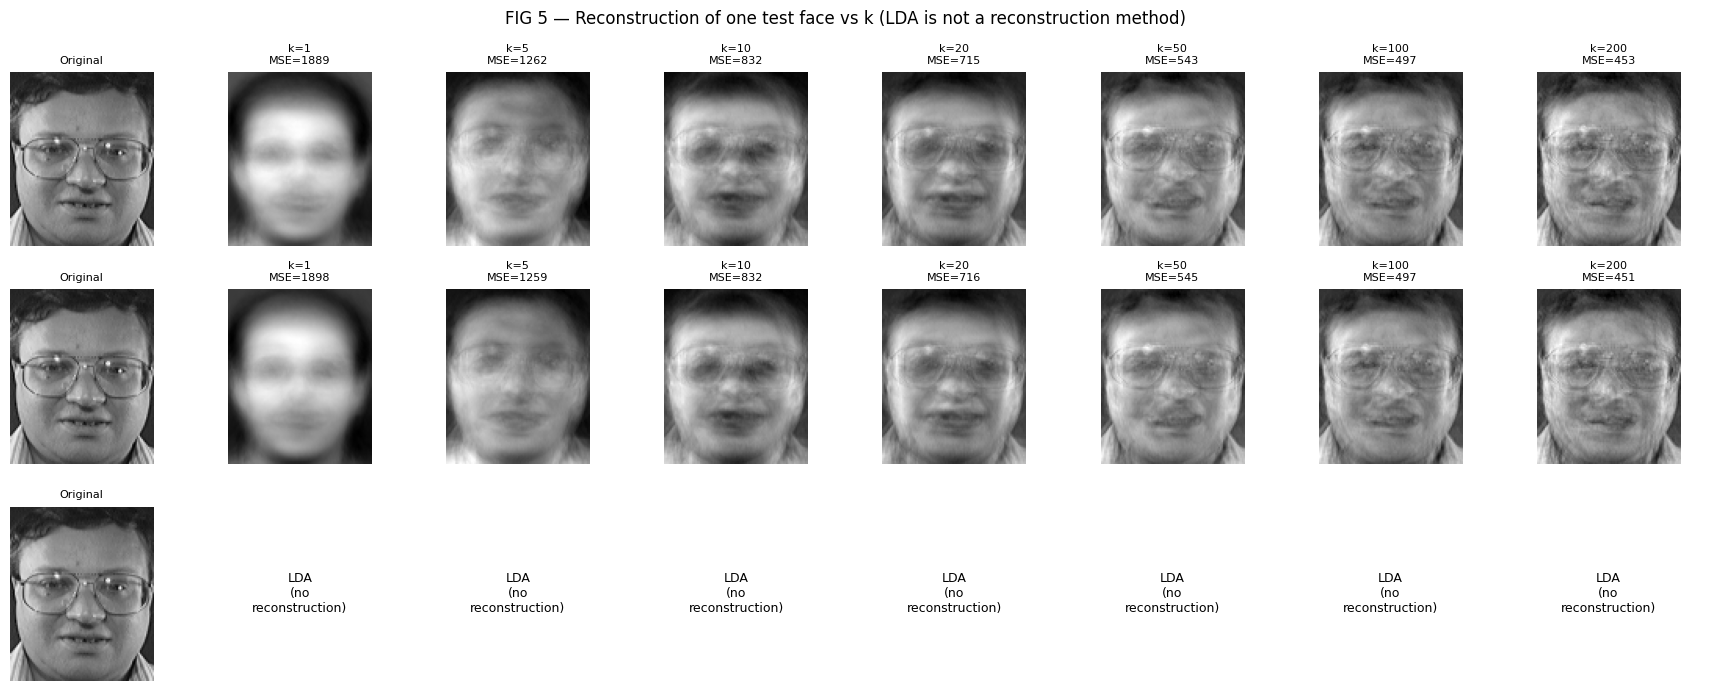

In [19]:
face = Xte[:1]
ks = [1, 5, 10, 20, 50, 100, 200]
fig, ax = plt.subplots(3, len(ks)+1, figsize=(2.2*(len(ks)+1), 7))

# original
for r in range(3):
    ax[r, 0].imshow(face.reshape(H, W), cmap='gray')
    ax[r, 0].set_title("Original", fontsize=8); ax[r, 0].axis('off')

for c, k in enumerate(ks):
    # PCA
    Rp = rec_pca(proj_pca(face, k), k)
    ax[0, c+1].imshow(Rp.reshape(H, W), cmap='gray')
    ax[0, c+1].set_title(f"k={k}\nMSE={np.mean((face-Rp)**2):.0f}", fontsize=8)
    ax[0, c+1].axis('off')
    # SVD
    Rs = rec_svd(proj_svd(face, k), k)
    ax[1, c+1].imshow(Rs.reshape(H, W), cmap='gray')
    ax[1, c+1].set_title(f"k={k}\nMSE={np.mean((face-Rs)**2):.0f}", fontsize=8)
    ax[1, c+1].axis('off')
    # LDA cannot reconstruct — show "-"
    ax[2, c+1].text(0.5, 0.5, "LDA\n(no\nreconstruction)", ha='center', va='center', fontsize=9)
    ax[2, c+1].axis('off')

ax[0,0].set_ylabel("PCA", fontsize=11)
ax[1,0].set_ylabel("SVD", fontsize=11)
ax[2,0].set_ylabel("LDA", fontsize=11)
plt.suptitle("FIG 5 — Reconstruction of one test face vs k (LDA is not a reconstruction method)", fontsize=12)
plt.tight_layout(); plt.show()

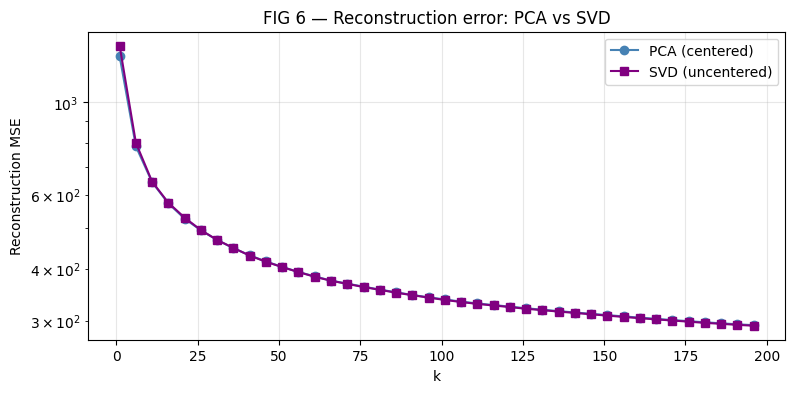

In [20]:
ks = list(range(1, 201, 5))
mse_pca, mse_svd = [], []
for k in ks:
    Rp = rec_pca(proj_pca(Xte, k), k); mse_pca.append(np.mean((Xte - Rp)**2))
    Rs = rec_svd(proj_svd(Xte, k), k); mse_svd.append(np.mean((Xte - Rs)**2))
plt.figure(figsize=(9, 4))
plt.plot(ks, mse_pca, 'o-', color='steelblue', label='PCA (centered)')
plt.plot(ks, mse_svd, 's-', color='purple',   label='SVD (uncentered)')
plt.xlabel("k"); plt.ylabel("Reconstruction MSE"); plt.yscale('log')
plt.title("FIG 6 — Reconstruction error: PCA vs SVD"); plt.legend(); plt.grid(alpha=.3); plt.show()

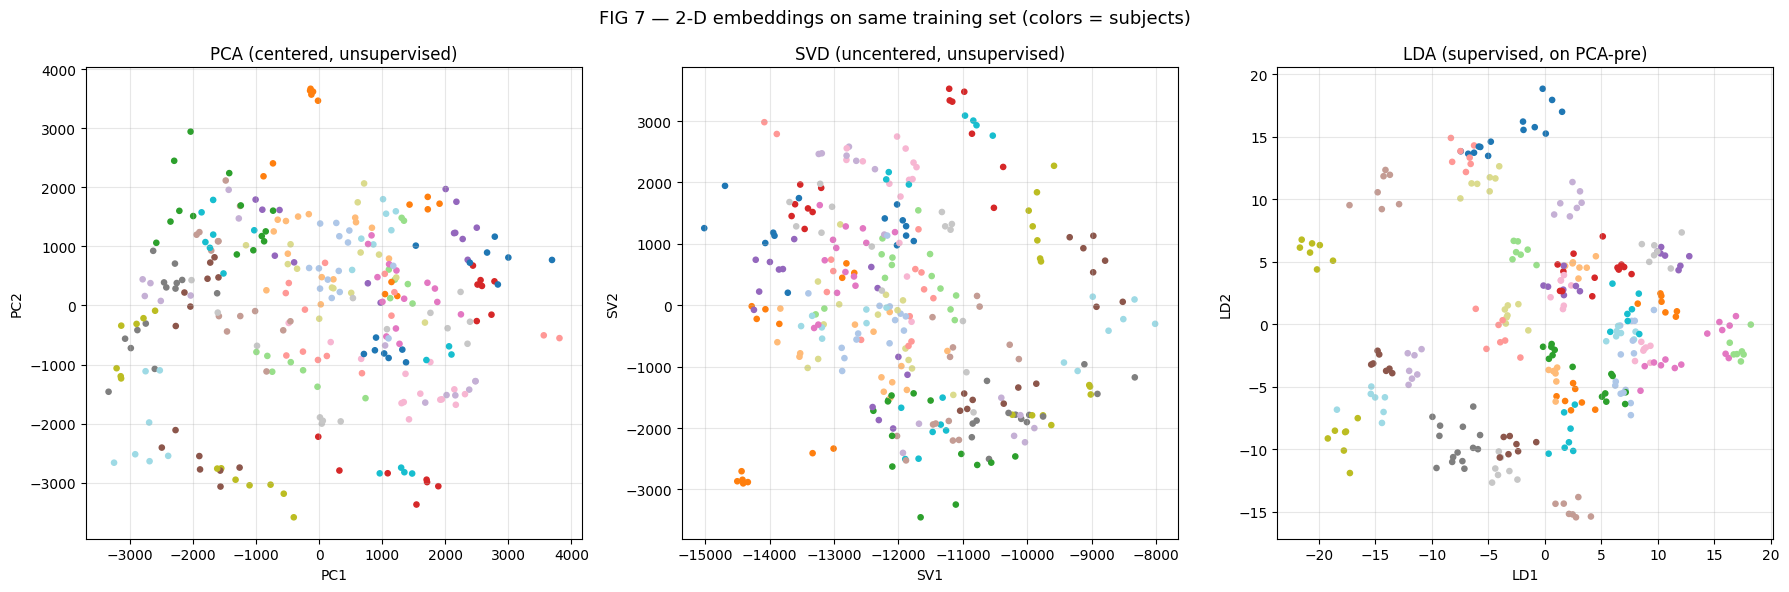

In [21]:
Zp = proj_pca(Xtr, 2)
Zs = proj_svd(Xtr, 2)
Zl = proj_lda(Xtr, 2)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, Z, name, xl, yl in zip(
        ax,
        [Zp, Zs, Zl],
        ["PCA (centered, unsupervised)",
         "SVD (uncentered, unsupervised)",
         "LDA (supervised, on PCA-pre)"],
        ["PC1", "SV1", "LD1"],
        ["PC2", "SV2", "LD2"]):
    sc = a.scatter(Z[:,0], Z[:,1], c=ytr, cmap='tab20', s=14)
    a.set_title(name); a.set_xlabel(xl); a.set_ylabel(yl); a.grid(alpha=.3)
plt.suptitle("FIG 7 — 2-D embeddings on same training set (colors = subjects)", fontsize=13)
plt.tight_layout(); plt.show()

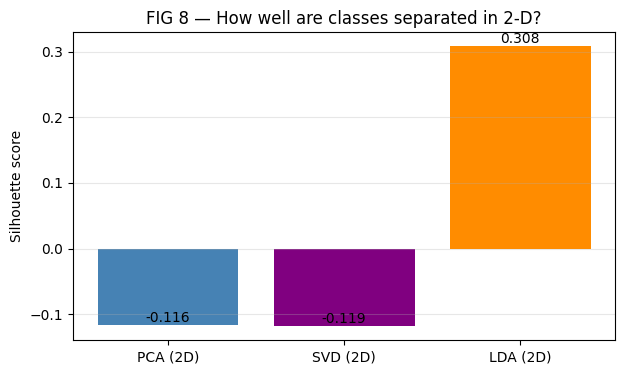

In [22]:
sub = np.random.choice(len(ytr), size=200, replace=False)
sil_pca = silhouette_score(Zp[sub], ytr[sub])
sil_svd = silhouette_score(Zs[sub], ytr[sub])
sil_lda = silhouette_score(Zl[sub], ytr[sub])

plt.figure(figsize=(7, 4))
bars = plt.bar(["PCA (2D)", "SVD (2D)", "LDA (2D)"],
               [sil_pca, sil_svd, sil_lda],
               color=['steelblue', 'purple', 'darkorange'])
plt.ylabel("Silhouette score"); plt.title("FIG 8 — How well are classes separated in 2-D?")
plt.grid(alpha=.3, axis='y')
for b, v in zip(bars, [sil_pca, sil_svd, sil_lda]):
    plt.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}", ha='center')
plt.show()

In [23]:
ks_pca = [5,10,20,30,40,50,75,100,150,200,250]
ks_svd = ks_pca
ks_lda = list(range(1, 40))

acc_pca, acc_svd, acc_lda = [], [], []

for k in ks_pca:
    Ztr_k = proj_pca(Xtr, k); Zte_k = proj_pca(Xte, k)
    acc_pca.append(accuracy_score(yte, KNeighborsClassifier(1).fit(Ztr_k, ytr).predict(Zte_k)))

for k in ks_svd:
    Ztr_k = proj_svd(Xtr, k); Zte_k = proj_svd(Xte, k)
    acc_svd.append(accuracy_score(yte, KNeighborsClassifier(1).fit(Ztr_k, ytr).predict(Zte_k)))

for k in ks_lda:
    clf = LinearDiscriminantAnalysis(n_components=k).fit(Xtr_p, ytr)
    Ztr_k = clf.transform(Xtr_p); Zte_k = clf.transform(Xte_p)
    acc_lda.append(accuracy_score(yte, KNeighborsClassifier(1).fit(Ztr_k, ytr).predict(Zte_k)))

best = {
    "PCA": (ks_pca[int(np.argmax(acc_pca))], max(acc_pca)),
    "SVD": (ks_svd[int(np.argmax(acc_svd))], max(acc_svd)),
    "LDA": (ks_lda[int(np.argmax(acc_lda))], max(acc_lda)),
}
print(best)

{'PCA': (50, 0.9916666666666667), 'SVD': (50, 0.9916666666666667), 'LDA': (19, 0.975)}


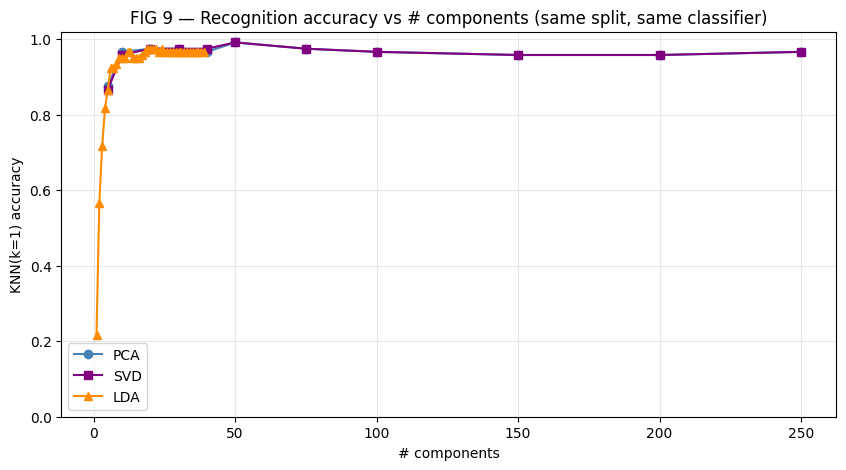

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(ks_pca, acc_pca, 'o-', color='steelblue', label='PCA')
plt.plot(ks_svd, acc_svd, 's-', color='purple',    label='SVD')
plt.plot(ks_lda, acc_lda, '^-', color='darkorange', label='LDA')
plt.xlabel("# components"); plt.ylabel("KNN(k=1) accuracy"); plt.ylim(0, 1.02)
plt.title("FIG 9 — Recognition accuracy vs # components (same split, same classifier)")
plt.legend(); plt.grid(alpha=.3); plt.show()

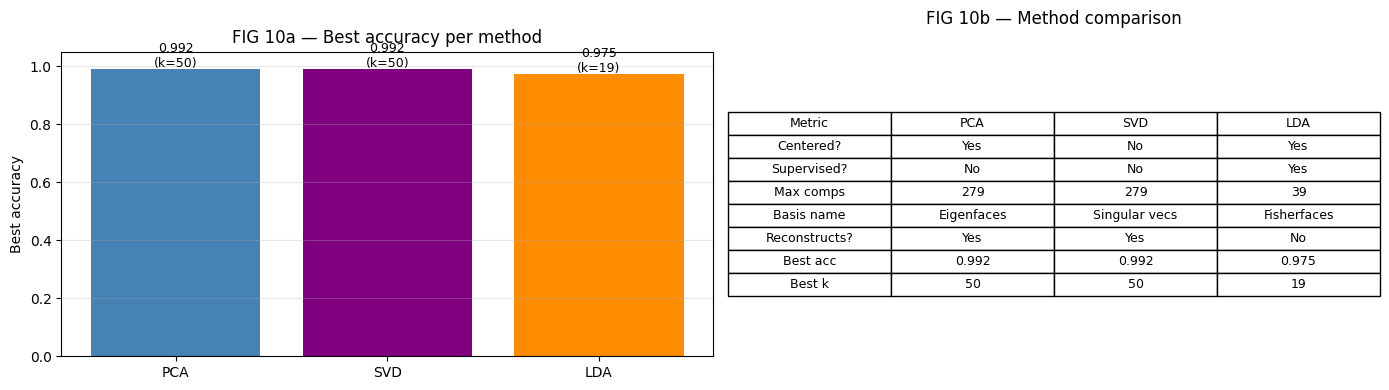

PCA   best acc = 0.9917  at k = 50
SVD   best acc = 0.9917  at k = 50
LDA   best acc = 0.9750  at k = 19


In [25]:
names = ["PCA", "SVD", "LDA"]
best_accs = [best["PCA"][1], best["SVD"][1], best["LDA"][1]]
best_ks  = [best["PCA"][0], best["SVD"][0], best["LDA"][0]]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bars = ax[0].bar(names, best_accs, color=['steelblue', 'purple', 'darkorange'])
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("Best accuracy")
ax[0].set_title("FIG 10a — Best accuracy per method")
for b, a, k in zip(bars, best_accs, best_ks):
    ax[0].text(b.get_x()+b.get_width()/2, a+0.005, f"{a:.3f}\n(k={k})", ha='center', fontsize=9)
ax[0].grid(alpha=.3, axis='y')

ax[1].axis('off')
table = [
    ["Metric", "PCA", "SVD", "LDA"],
    ["Centered?", "Yes", "No", "Yes"],
    ["Supervised?", "No", "No", "Yes"],
    ["Max comps", "279", "279", "39"],
    ["Basis name", "Eigenfaces", "Singular vecs", "Fisherfaces"],
    ["Reconstructs?", "Yes", "Yes", "No"],
    [f"Best acc", f"{best['PCA'][1]:.3f}", f"{best['SVD'][1]:.3f}", f"{best['LDA'][1]:.3f}"],
    [f"Best k", best["PCA"][0], best["SVD"][0], best["LDA"][0]],
]
t = ax[1].table(cellText=table, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.4)
ax[1].set_title("FIG 10b — Method comparison", pad=20)
plt.tight_layout(); plt.show()

for n, a, k in zip(names, best_accs, best_ks):
    print(f"{n:4s}  best acc = {a:.4f}  at k = {k}")

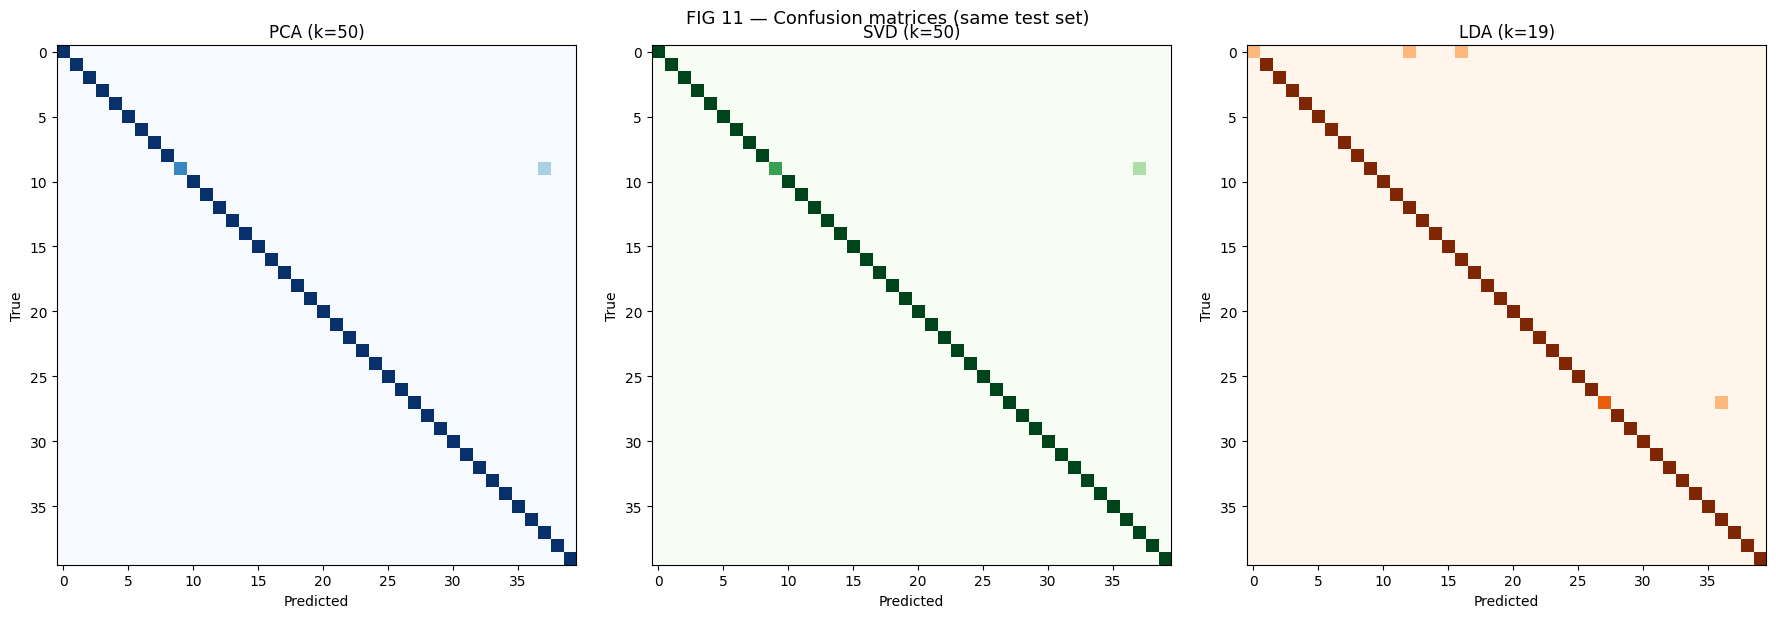

In [26]:
# PCA
Zp_tr = proj_pca(Xtr, best["PCA"][0]); Zp_te = proj_pca(Xte, best["PCA"][0])
pred_pca = KNeighborsClassifier(1).fit(Zp_tr, ytr).predict(Zp_te)
cm_pca = confusion_matrix(yte, pred_pca)

# SVD
Zs_tr = proj_svd(Xtr, best["SVD"][0]); Zs_te = proj_svd(Xte, best["SVD"][0])
pred_svd = KNeighborsClassifier(1).fit(Zs_tr, ytr).predict(Zs_te)
cm_svd = confusion_matrix(yte, pred_svd)

# LDA
clf = LinearDiscriminantAnalysis(n_components=best["LDA"][0]).fit(Xtr_p, ytr)
Zl_tr = clf.transform(Xtr_p); Zl_te = clf.transform(Xte_p)
pred_lda = KNeighborsClassifier(1).fit(Zl_tr, ytr).predict(Zl_te)
cm_lda = confusion_matrix(yte, pred_lda)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, cm, name, cmap in zip(
        ax,
        [cm_pca, cm_svd, cm_lda],
        [f"PCA (k={best['PCA'][0]})",
         f"SVD (k={best['SVD'][0]})",
         f"LDA (k={best['LDA'][0]})"],
        ['Blues', 'Greens', 'Oranges']):
    a.imshow(cm, cmap=cmap); a.set_title(name); a.set_xlabel("Predicted"); a.set_ylabel("True")
plt.suptitle("FIG 11 — Confusion matrices (same test set)", fontsize=13)
plt.tight_layout(); plt.show()

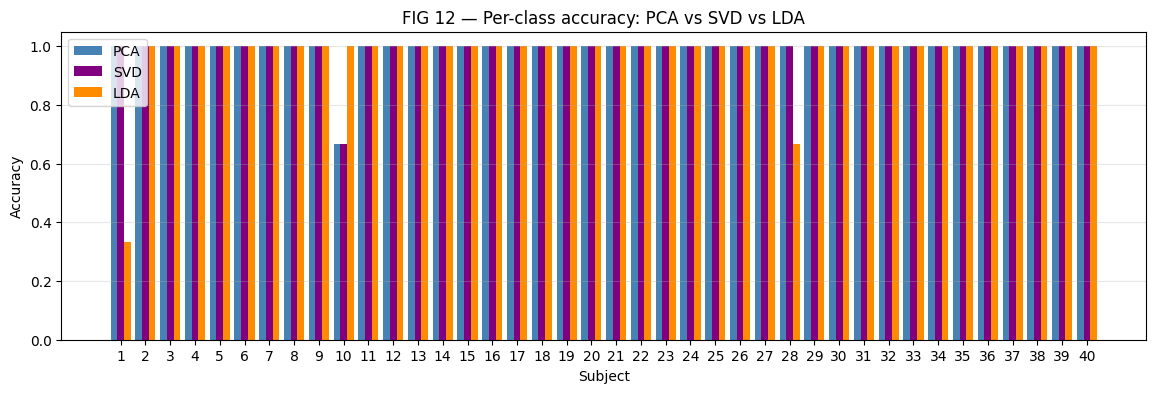

In [27]:
per_pca = cm_pca.diagonal() / cm_pca.sum(axis=1)
per_svd = cm_svd.diagonal() / cm_svd.sum(axis=1)
per_lda = cm_lda.diagonal() / cm_lda.sum(axis=1)

x = np.arange(1, 41)
w = 0.27
plt.figure(figsize=(14, 4))
plt.bar(x - w, per_pca, width=w, label='PCA', color='steelblue')
plt.bar(x,     per_svd, width=w, label='SVD', color='purple')
plt.bar(x + w, per_lda, width=w, label='LDA', color='darkorange')
plt.xticks(x); plt.ylim(0, 1.05)
plt.xlabel("Subject"); plt.ylabel("Accuracy")
plt.title("FIG 12 — Per-class accuracy: PCA vs SVD vs LDA")
plt.legend(); plt.grid(alpha=.3, axis='y'); plt.show()

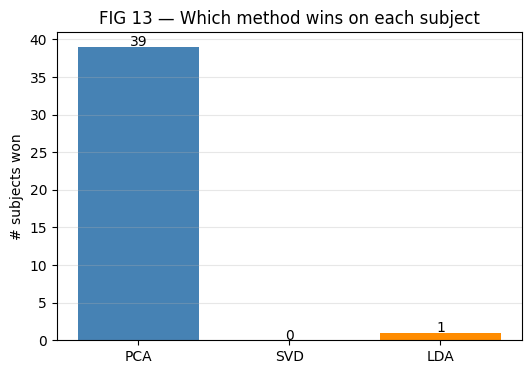

In [28]:
stack = np.vstack([per_pca, per_svd, per_lda])          # 3 × 40
winner = np.argmax(stack, axis=0)                        # 0=PCA,1=SVD,2=LDA
counts = np.bincount(winner, minlength=3)

plt.figure(figsize=(6, 4))
plt.bar(["PCA", "SVD", "LDA"], counts, color=['steelblue','purple','darkorange'])
plt.ylabel("# subjects won"); plt.title("FIG 13 — Which method wins on each subject")
for i, c in enumerate(counts):
    plt.text(i, c + 0.1, str(c), ha='center')
plt.grid(alpha=.3, axis='y'); plt.show()

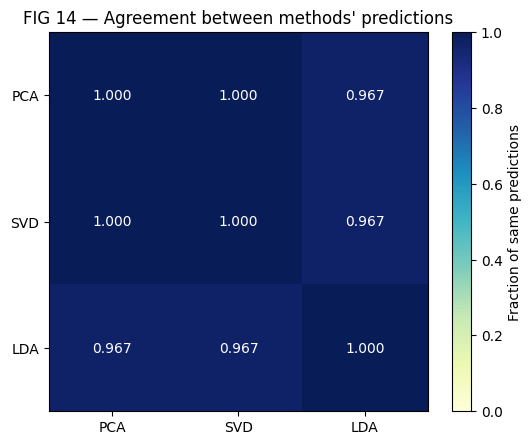

In [29]:
# Pairwise prediction agreement
agree_pca_svd = np.mean(pred_pca == pred_svd)
agree_pca_lda = np.mean(pred_pca == pred_lda)
agree_svd_lda = np.mean(pred_svd == pred_lda)

M = np.array([[1.0, agree_pca_svd, agree_pca_lda],
              [agree_pca_svd, 1.0, agree_svd_lda],
              [agree_pca_lda, agree_svd_lda, 1.0]])

plt.figure(figsize=(5.5, 4.5))
plt.imshow(M, cmap='YlGnBu', vmin=0, vmax=1); plt.colorbar(label="Fraction of same predictions")
plt.xticks([0,1,2], ["PCA","SVD","LDA"]); plt.yticks([0,1,2], ["PCA","SVD","LDA"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{M[i,j]:.3f}", ha='center', va='center',
                 color='white' if M[i,j] > 0.6 else 'black')
plt.title("FIG 14 — Agreement between methods' predictions")
plt.tight_layout(); plt.show()

In [30]:
print("=" * 60)
print("FINAL SUMMARY — same ORL split, same KNN(k=1) classifier")
print("=" * 60)
for n, a, k in zip(names, best_accs, best_ks):
    print(f"{n:4s} | best acc = {a:.4f} | at k = {k:3d}")
print("-" * 60)
print(f"Highest accuracy: {names[int(np.argmax(best_accs))]} "
      f"({max(best_accs):.4f})")
print(f"Silhouette (2-D)  PCA={sil_pca:.3f}  SVD={sil_svd:.3f}  LDA={sil_lda:.3f}")
print(f"Reconstruction 95% energy: PCA k={k_pca_95},  SVD k={k_svd_95}")

FINAL SUMMARY — same ORL split, same KNN(k=1) classifier
PCA  | best acc = 0.9917 | at k =  50
SVD  | best acc = 0.9917 | at k =  50
LDA  | best acc = 0.9750 | at k =  19
------------------------------------------------------------
Highest accuracy: PCA (0.9917)
Silhouette (2-D)  PCA=-0.116  SVD=-0.119  LDA=0.308
Reconstruction 95% energy: PCA k=147,  SVD k=7
